# Oil Palm Disease Classification using ALOS-2 SAR

**Postgraduate Research** — Prerequisites & Environment Setup

This notebook sets up the full environment for processing ALOS-2 PALSAR-2 data on **Google Colab**:
- **ESA SNAP 13.0.0** (Sentinel Toolboxes) — SAR processing engine
- **esa_snappy** — Python bridge to SNAP's Java API
- **Scientific Python stack** — numpy, rasterio, scikit-learn, etc.

Persistent storage uses **Google Cloud Storage** (SNAP binary cached in a bucket to avoid re-downloading on each session).

---

## Prerequisites

### 0. Authenticate GCS & Set Project Root

**Before running**: create a GCS bucket at https://console.cloud.google.com/storage and
set `GCS_BUCKET` below to your bucket name.

SNAP (~1.5 GB) will be cached in `gs://<bucket>/snap/` so it only needs to be downloaded from ESA once.

In [1]:
from google.colab import auth
auth.authenticate_user()

# --- CONFIGURE THESE ---
GCS_BUCKET = "sar-oilpalm"          # your GCS bucket name (no gs://)
PROJECT_ROOT = "/content/SAR-OilPalm"  # local working dir on Colab VM
# -----------------------

import os
os.makedirs(f"{PROJECT_ROOT}/data", exist_ok=True)
os.makedirs(f"{PROJECT_ROOT}/snap", exist_ok=True)
os.chdir(PROJECT_ROOT)

print(f"GCS bucket: gs://{GCS_BUCKET}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Working directory: {os.getcwd()}")

# Verify GCS access
!gsutil ls "gs://{GCS_BUCKET}" > /dev/null 2>&1 && echo "GCS access OK" || echo "GCS access FAILED — check bucket name and permissions"

GCS bucket: gs://sar-oilpalm
Project root: /content/SAR-OilPalm
Working directory: /content/SAR-OilPalm
GCS access OK


### 1. System Setup — Python Dependencies

Installs `uv`, then installs all Python packages to the Colab system Python via `uv pip install --system`.

In [2]:
# System checks
import platform, sys, shutil, os
print(f"Platform: {platform.system()} {platform.release()}")
print(f"Architecture: {platform.machine()}")
print(f"Python: {sys.version}")
print(f"wget: {shutil.which('wget') or 'not found'}")
print(f"curl: {shutil.which('curl') or 'not found'}")
print(f"java: {shutil.which('java') or 'not found (SNAP bundles its own JRE)'}")

Platform: Linux 6.6.122+
Architecture: x86_64
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
wget: /usr/bin/wget
curl: /usr/bin/curl
java: /usr/bin/java


In [3]:
%%bash
set -e

PROJECT_ROOT="/content/SAR-OilPalm"
cd "$PROJECT_ROOT"

echo "Installing uv..."
pip install uv -q
echo "uv: $(uv --version)"

echo "Installing packages to Colab system Python..."
uv pip install --system \
    esa-snappy \
    "numpy>=1.26" scipy \
    matplotlib seaborn \
    rasterio rioxarray \
    geopandas shapely pyproj \
    scikit-learn \
    jupyter ipykernel ipywidgets \
    tqdm joblib

echo ""
echo "=== Environment ready ==="
python --version

Installing uv...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.9/26.9 MB 57.9 MB/s eta 0:00:00
uv: uv 0.11.29 (x86_64-unknown-linux-gnu)
Installing packages to Colab system Python...

=== Environment ready ===
Python 3.12.13


Using Python 3.12.13 environment at: /usr
Resolved 125 packages in 1.19s
Prepared 11 packages in 1.47s
Uninstalled 1 package in 12ms
Installed 11 packages in 169ms
 + async-lru==2.3.0
 + esa-snappy==1.1.2
 + jedi==0.20.0
 + json5==0.15.0
 + jupyter==1.1.1
 + jupyter-builder==1.1.1
 + jupyter-lsp==2.3.1
 + jupyterlab==4.6.1
 + jupyterlab-server==2.28.0
 + rioxarray==0.22.0
 - xarray==2025.12.0
 + xarray==2026.7.0


### 2. Download & Install ESA SNAP 13.0.0

Restores SNAP from the GCS cache if available, otherwise downloads the installer from ESA,
installs it, and caches the result on GCS for future sessions.

In [4]:
%%bash
set -e

PROJECT_ROOT="/content/SAR-OilPalm"
GCS_BUCKET="sar-oilpalm"
SNAP_HOME="$PROJECT_ROOT/snap"
INSTALLER="esa-snap_sentinel_linux-13.0.0.sh"
INSTALLER_URL="https://download.esa.int/step/snap/13.0/installers/${INSTALLER}"
GCS_SNAP_CACHE="gs://$GCS_BUCKET/snap-13.0.0.tar.gz"

# Check if SNAP is already installed locally
if [ -f "$SNAP_HOME/bin/snap" ]; then
    echo "SNAP already installed at $SNAP_HOME — skipping"
    ls -la "$SNAP_HOME/bin/" | head -5
    exit 0
fi

restore_from_cache() {
    echo "Restoring SNAP from GCS cache..."
    gsutil cp "$GCS_SNAP_CACHE" - | tar xzf - -C "$PROJECT_ROOT"
    echo "SNAP restored to $SNAP_HOME"
    return 0
}

# Try restoring from GCS cache first
if gsutil -q stat "$GCS_SNAP_CACHE" 2>/dev/null; then
    restore_from_cache
    exit 0
fi

echo "No GCS cache found — downloading from ESA..."

# Download installer (cache the installer on GCS too)
GCS_INSTALLER_CACHE="gs://$GCS_BUCKET/installers/$INSTALLER"
if gsutil -q stat "$GCS_INSTALLER_CACHE" 2>/dev/null; then
    echo "Downloading installer from GCS cache..."
    gsutil cp "$GCS_INSTALLER_CACHE" "$INSTALLER"
else
    echo "Downloading installer from ESA (~1 GB)..."
    wget "$INSTALLER_URL" -O "$INSTALLER"
    gsutil cp "$INSTALLER" "$GCS_INSTALLER_CACHE"
fi
chmod +x "$INSTALLER"
echo "Installer ready: $(du -h $INSTALLER | cut -f1)"

# Create response file for quiet headless install
cat > response.varfile << 'EOF'
sys.adminRights$Boolean=false
sys.component.RSTB$Boolean=true
sys.component.S1TBX$Boolean=true
sys.component.S2TBX$Boolean=true
sys.component.S3TBX$Boolean=false
sys.component.SNAP$Boolean=true
sys.installationDir=__SNAP_HOME__
sys.languageId=en
sys.programGroupDisabled$Boolean=true
createDesktopLinkAction$Boolean=false
executeLauncherWithPythonAction$Boolean=false
deleteSnapDir$Boolean=false
EOF
sed -i "s|__SNAP_HOME__|$SNAP_HOME|" response.varfile

# Run installer in quiet mode
mkdir -p "$SNAP_HOME"
echo "Installing SNAP to $SNAP_HOME (this may take a few minutes)..."
bash "$INSTALLER" -q -varfile response.varfile
echo "SNAP installation complete"

# Cache the installed SNAP on GCS for next session
echo "Caching SNAP installation on GCS..."
tar czf /tmp/snap-13.0.0.tar.gz -C "$PROJECT_ROOT" snap
gsutil cp /tmp/snap-13.0.0.tar.gz "$GCS_SNAP_CACHE"
rm -f /tmp/snap-13.0.0.tar.gz
echo "SNAP cached at $GCS_SNAP_CACHE"

ls -la "$SNAP_HOME/bin/" | head -5

Restoring SNAP from GCS cache...
SNAP restored to /content/SAR-OilPalm/snap


### 3. Configure esa_snappy (SNAP ↔ Python Bridge)

Connects SNAP's Java engine to the Colab system Python.

In [5]:
%%bash
set -e

PROJECT_ROOT="/content/SAR-OilPalm"
SNAP_HOME="$PROJECT_ROOT/snap"

export PATH="$SNAP_HOME/bin:$PATH"

echo "=== Running snappy-conf ==="
"$SNAP_HOME/bin/snappy-conf" "$(which python)"

echo ""
echo "=== GPT CLI ==="
"$SNAP_HOME/bin/gpt" -h 2>&1 | head -8 || true

echo ""
echo "=== Setup Complete ==="

=== Running snappy-conf ===
Configuring ESA SNAP-Python interface...
Found esa_snappy installed in '/usr/local/lib/python3.12/dist-packages'
Starting configuration...
Configuration finished successful!
Done. The SNAP-Python interface is located in '/usr/local/lib/python3.12/dist-packages/esa_snappy'
The executable of the Python environment is located at '/usr/local/bin/python'

=== GPT CLI ===
INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.
Usage:
  gpt <op>|<graph-file> [options] [<source-file-1> <source-file-2> ...]

Description:
  This tool is used to execute SNAP raster data operators in batch-mode. The
  operators can be used stand-alone or combined as a directed acyclic graph

=== Setup Complete ===


OpenJDK 64-Bit Server VM warning: Options -Xverify:none and -noverify were deprecated in JDK 13 and will likely be removed in a future release.


In [6]:
import esa_snappy
from esa_snappy import ProductIO, GPF
print('OK - esa_snappy is configured and ready')

OK - esa_snappy is configured and ready


### 4. Quick Test

Verifies the full pipeline — `esa_snappy` imports and SNAP GPT CLI.

In [7]:
print('esa_snappy is ready for ALOS-2 SAR processing')
ops = GPF.getDefaultInstance().getOperatorSpiRegistry().getOperatorSpis()
print(f'Available operators: {ops.size()}')

esa_snappy is ready for ALOS-2 SAR processing
Available operators: 156


---
## Extraction of SAR BackScatter Intensity
- From the SHP file, identify the tree's coords (Lat, Long) then extract the dB (HH, VV, VH) from scene files.
- Since the SAR scene resolution might not be enough, any trees within the same resolution cell share the same dB of backscatter
- From the csv file, merge the health status to its responding tree based on coords

_SAR scene_ located at: `gs://$GCS_BUCKET/data/SAR-scenes`\
The SAR scene folder contains one or more `<scene>.data` folder and `<scene>.dim`.

_SHP zip_ located at: `gs://$GCS_BUCKET/data/SHP-files`\
The SHP zip contains files that are named by its location, `<location>.cpg/.dbf/.prj/.qmd/.shp/.shx`

_Label csv zip_ located at: `gs://$GCS_BUCKET/data/Label-status`\
The Label zip contains files that are named by its location aswell, `<location>.csv/.cpg/.dbf/.prj/.qmd/.shp/.shx`

### 5. Configuration & Data Download

Single ALOS-2 PALSAR-2 scene (fully polarimetric, `Cal_ML_Spk_TC` preprocessed) covers both Palong and Serting sites. Tree centroids, labels, and the SAR scene are downloaded from GCS if not cached locally.

In [18]:
import os
import glob

GCS_BUCKET  = "sar-oilpalm"
SCENE_NAME  = "ALOS2-HBQR1_1__D-ORBIT__ALOS2650583560-260610_Cal_ML_Spk_TC"

DATA_DIR     = f"{PROJECT_ROOT}/data"
SCENE_DIR    = f"{DATA_DIR}/SAR-scenes"
OUTPUT_DIR   = f"{DATA_DIR}/processed"

LOCAL_DIM_PATH     = f"{SCENE_DIR}/{SCENE_NAME}.dim"
LOCAL_GEOTIFF_PATH = f"{SCENE_DIR}/{SCENE_NAME}_dB.tif"

LOCATIONS = ["Palong_Basemap", "Serting_Basemap"]

for d in [SCENE_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

# --- Download SHP + Label zips from GCS (gcloud storage CLI, replaces gsutil) ---
# The zips may extract to a different folder name than expected (e.g., Result/
# instead of Label_Palong2022/), so we glob for the actual CSV/SHP afterwards.
for subdir, zip_name in [("SHP-files", "SHP_Palong2022.zip"),
                         ("Label-status", "Label_Palong2022.zip")]:
    extracted_root = f"{DATA_DIR}/{subdir}"
    already_there = glob.glob(f"{extracted_root}/**/*Classification.csv", recursive=True) \
                    + glob.glob(f"{extracted_root}/**/*centroid.shp", recursive=True)
    if already_there:
        print(f"[OK] {subdir} already extracted ({len(already_there)} files found)")
        continue
    os.makedirs(extracted_root, exist_ok=True)
    gcs_path  = f"gs://{GCS_BUCKET}/data/{subdir}/{zip_name}"
    local_zip = f"{extracted_root}/{zip_name}"
    print(f"Downloading {zip_name} from GCS via gcloud storage...")
    !gcloud storage cp "{gcs_path}" "{local_zip}"
    !unzip -q -o "{local_zip}" -d "{extracted_root}"
    if os.path.exists(local_zip):
        os.remove(local_zip)
    print(f"  -> extracted to {extracted_root}")

# --- Locate label folder dynamically ---
# Zip may extract to Label_Palong2022/, Result/, or directly. Glob handles all cases.
LABEL_DIR = None
for location in LOCATIONS:
    matches = glob.glob(
        f"{DATA_DIR}/Label-status/**/{location} Classification.csv",
        recursive=True
    )
    if matches:
        LABEL_DIR = os.path.dirname(matches[0])
        break
if LABEL_DIR is None:
    raise FileNotFoundError(
        f"Could not find any '<location> Classification.csv' under {DATA_DIR}/Label-status/. "
        f"Check that the zip extracted correctly."
    )
print(f"Label folder (LABEL_DIR): {LABEL_DIR}")

# --- Locate SHP folder dynamically (kept for future use; not required for dB extraction) ---
SHP_DIR = None
for location in LOCATIONS:
    matches = glob.glob(
        f"{DATA_DIR}/SHP-files/**/{location}*.shp",
        recursive=True
    )
    if matches:
        SHP_DIR = os.path.dirname(matches[0])
        break
print(f"SHP folder   (SHP_DIR):   {SHP_DIR or '(not found)'}")

# --- Download SAR scene from GCS ---
if not os.path.exists(LOCAL_DIM_PATH):
    gcs_prefix = f"gs://{GCS_BUCKET}/data/SAR-scenes/{SCENE_NAME}"
    print(f"\nDownloading SAR scene from GCS via gcloud storage (may take a while)...")
    !gcloud storage cp -r "{gcs_prefix}*" "{SCENE_DIR}/"
    print(f"  -> {SCENE_DIR}")
else:
    print(f"\n[OK] SAR scene already present")

print(f"\n=== Config ===")
print(f"Scene:     {SCENE_NAME}")
print(f"Locations: {LOCATIONS}")
print(f"GeoTIFF:   {LOCAL_GEOTIFF_PATH}")
print(f"Output:    {OUTPUT_DIR}")

[OK] SHP-files already extracted (2 files found)
[OK] Label-status already extracted (2 files found)
Label folder (LABEL_DIR): /content/SAR-OilPalm/data/Label-status/Result
SHP folder   (SHP_DIR):   /content/SAR-OilPalm/data/SHP-files

[OK] SAR scene already present

=== Config ===
Scene:     ALOS2-HBQR1_1__D-ORBIT__ALOS2650583560-260610_Cal_ML_Spk_TC
Locations: ['Palong_Basemap', 'Serting_Basemap']
GeoTIFF:   /content/SAR-OilPalm/data/SAR-scenes/ALOS2-HBQR1_1__D-ORBIT__ALOS2650583560-260610_Cal_ML_Spk_TC_dB.tif
Output:    /content/SAR-OilPalm/data/processed


### 6. Inspect SAR Scene

Read the `.dim` product with `esa_snappy`, list available bands, and detect whether values are in linear or dB scale.

In [19]:
from esa_snappy import ProductIO
import numpy as np

product = ProductIO.readProduct(LOCAL_DIM_PATH)
band_names = list(product.getBandNames())
print(f"Product: {product.getName()}")
print(f"Bands ({len(band_names)}):")
for bn in band_names:
    print(f"  - {bn}")

# Map band names to polarization
def extract_pol(name):
    u = name.upper()
    for pol in ['HH', 'HV', 'VV', 'VH']:
        if pol in u:
            return pol
    return None

pol_bands = {}
for name in band_names:
    pol = extract_pol(name)
    if pol and pol not in pol_bands:
        pol_bands[pol] = name

POL_ORDER = ['HH', 'HV', 'VV', 'VH']
available_pols = [p for p in POL_ORDER if p in pol_bands]
print(f"\nPolarizations found: {available_pols}")
print(f"Band mapping: {pol_bands}")

# Sample from the CENTER of the scene (borders are often zero-padded in TC products)
def read_sample_region(band, x0, y0, sw, sh):
    buf = np.zeros(sw * sh, dtype=np.float32)
    band.readPixels(x0, y0, sw, sh, buf)
    return buf.reshape(sh, sw)

sample_band = product.getBand(band_names[0])
w, h = sample_band.getRasterWidth(), sample_band.getRasterHeight()
sw, sh = min(500, w), min(500, h)
x0 = max(0, (w - sw) // 2)
y0 = max(0, (h - sh) // 2)

sample = read_sample_region(sample_band, x0, y0, sw, sh)
valid = sample[sample != 0]

# Fallback: if center is all zero, try 3 random regions (deterministic seed)
if len(valid) == 0:
    print(f"\nCenter region is all zero -- sampling 3 random regions as fallback")
    rng = np.random.default_rng(42)
    all_vals = []
    rs = 300
    for _ in range(3):
        rx = int(rng.integers(0, max(1, w - rs)))
        ry = int(rng.integers(0, max(1, h - rs)))
        s = read_sample_region(sample_band, rx, ry, rs, rs)
        all_vals.extend(s[s != 0].tolist())
    valid = np.array(all_vals) if all_vals else np.array([])

if len(valid) > 0:
    vmin, vmax, vmean = valid.min(), valid.max(), valid.mean()
    has_negative = vmin < 0
    print(f"\nSample stats ({band_names[0]}):")
    print(f"  n_valid={len(valid)}  min={vmin:.4f}  max={vmax:.4f}  mean={vmean:.4f}")
    print(f"  has_negative={has_negative}")

    # Better heuristic: dB has negative values; linear sigma0 is always >= 0
    if has_negative:
        is_db = True
        scale_label = "dB (has negative values -- no conversion needed)"
    elif vmax < 1.0 and vmean < 0.5:
        is_db = False
        scale_label = "Linear (all positive, max < 1.0 -- will convert to dB)"
    else:
        # Ambiguous: max >= 1 and no negatives. Could be linear with strong scatterers
        # or already-dB with a very bright target. Default to linear (safer to convert
        # than to skip conversion on truly linear data).
        is_db = False
        scale_label = "Linear (no negatives, max >= 1.0 -- assuming linear, will convert)"
    print(f"  Detected scale: {scale_label}")
else:
    print(f"\nERROR: All sampled pixels are zero across center + 3 random regions.")
    print(f"       Scene may be corrupted or bands are stored differently than expected.")
    is_db = False  # conservative default

product.dispose()

Product: ALOS2-HBQR1_1__D-ORBIT__ALOS2650583560-260610_Cal_ML_Spk_TC
Bands (8):
  - Sigma0_HH
  - Sigma0_HV
  - Sigma0_VH
  - Sigma0_VV
  - Sigma0_HH_db
  - Sigma0_HV_db
  - Sigma0_VH_db
  - Sigma0_VV_db

Polarizations found: ['HH', 'HV', 'VV', 'VH']
Band mapping: {'HH': 'Sigma0_HH', 'HV': 'Sigma0_HV', 'VH': 'Sigma0_VH', 'VV': 'Sigma0_VV'}

Sample stats (Sigma0_HH):
  n_valid=250000  min=0.0134  max=7.2559  mean=0.1657
  has_negative=False
  Detected scale: Linear (no negatives, max >= 1.0 -- assuming linear, will convert)


### 7. Export to GeoTIFF (SNAP GPT)

Build a GPT graph that:
1. Reads the `.dim` product
2. Selects only HH, HV, VV, VH bands (`BandSelect`)
3. Converts linear sigma0 -> dB via `LinearToFromdB` (skipped if already in dB)
4. Writes a stacked GeoTIFF for efficient point sampling with `rasterio`

In [21]:
import subprocess

FORCE_REEXPORT = False  # Set True to force re-export even if GeoTIFF exists

if os.path.exists(LOCAL_GEOTIFF_PATH) and not FORCE_REEXPORT:
    print(f"[OK] GeoTIFF already exists: {LOCAL_GEOTIFF_PATH}")
    print("     (Set FORCE_REEXPORT=True to re-export)")
else:
    selected_band_names = [pol_bands[p] for p in available_pols]
    band_list_str = ",".join(selected_band_names)

    read_node = f"""  <node id="Read">
    <operator>Read</operator>
    <sources/>
    <parameters>
      <file>{LOCAL_DIM_PATH}</file>
    </parameters>
  </node>"""

    select_node = f"""  <node id="BandSelect">
    <operator>BandSelect</operator>
    <sources>
      <sourceProduct refid="Read"/>
    </sources>
    <parameters>
      <sourceBands>{band_list_str}</sourceBands>
    </parameters>
  </node>"""

    if is_db:
        last_ref = "BandSelect"
        db_node = ""
    else:
        last_ref = "ToDB"
        db_node = f"""
  <node id="ToDB">
    <operator>LinearToFromdB</operator>
    <sources>
      <sourceProduct refid="BandSelect"/>
    </sources>
  </node>"""

    write_node = f"""  <node id="Write">
    <operator>Write</operator>
    <sources>
      <sourceProduct refid="{last_ref}"/>
    </sources>
    <parameters>
      <file>{LOCAL_GEOTIFF_PATH}</file>
      <formatName>GeoTIFF-BigTIFF</formatName>
    </parameters>
  </node>"""

    graph_xml = f"""<graph id="sar_to_db_geotiff">
  <version>1.0</version>
{read_node}
{select_node}
{db_node}
{write_node}
</graph>"""

    graph_path = f"{SCENE_DIR}/sar_to_db.xml"
    with open(graph_path, 'w') as f:
        f.write(graph_xml)
    print(f"Graph written to {graph_path}")
    print(f"\n--- Graph XML ---\n{graph_xml}")

    # Run GPT
    gpt_bin = f"{PROJECT_ROOT}/snap/bin/gpt"
    env = os.environ.copy()
    env['SNAP_HOME'] = f"{PROJECT_ROOT}/snap"
    env['PATH'] = f"{PROJECT_ROOT}/snap/bin:{env.get('PATH', '')}"

    print(f"\nRunning GPT (this may take a few minutes)...")
    result = subprocess.run(
        [gpt_bin, graph_path],
        capture_output=True, text=True, env=env
    )
    print(f"Exit code: {result.returncode}")
    if result.stdout:
        print(f"stdout (last 500 chars):\n{result.stdout[-500:]}")
    if result.stderr:
        print(f"stderr (last 500 chars):\n{result.stderr[-500:]}")

    if result.returncode != 0:
        raise RuntimeError(f"GPT failed with exit code {result.returncode}")

    size_mb = os.path.getsize(LOCAL_GEOTIFF_PATH) / (1024 * 1024)
    print(f"\n[OK] GeoTIFF created: {LOCAL_GEOTIFF_PATH} ({size_mb:.1f} MB)")

Graph written to /content/SAR-OilPalm/data/SAR-scenes/sar_to_db.xml

--- Graph XML ---
<graph id="sar_to_db_geotiff">
  <version>1.0</version>
  <node id="Read">
    <operator>Read</operator>
    <sources/>
    <parameters>
      <file>/content/SAR-OilPalm/data/SAR-scenes/ALOS2-HBQR1_1__D-ORBIT__ALOS2650583560-260610_Cal_ML_Spk_TC.dim</file>
    </parameters>
  </node>
  <node id="BandSelect">
    <operator>BandSelect</operator>
    <sources>
      <sourceProduct refid="Read"/>
    </sources>
    <parameters>
      <sourceBands>Sigma0_HH,Sigma0_HV,Sigma0_VV,Sigma0_VH</sourceBands>
    </parameters>
  </node>

  <node id="ToDB">
    <operator>LinearToFromdB</operator>
    <sources>
      <sourceProduct refid="BandSelect"/>
    </sources>
  </node>
  <node id="Write">
    <operator>Write</operator>
    <sources>
      <sourceProduct refid="ToDB"/>
    </sources>
    <parameters>
      <file>/content/SAR-OilPalm/data/SAR-scenes/ALOS2-HBQR1_1__D-ORBIT__ALOS2650583560-260610_Cal_ML_Spk_TC_d

### 8. Sample dB at Tree Coordinates & Build Dataset

For each tree `(id, Long, Lat)` in the label CSVs:
1. Reproject WGS-84 -> scene CRS (UTM) via `rasterio.warp.transform`
2. Sample the GeoTIFF at the reprojected coordinate
3. Trees in the same SAR resolution cell share the same dB value automatically
4. Compute `HHHVRatio = HH_dB - HV_dB` (dB difference, physically meaningful)
5. Map `Class` -> `Health` (1:1), set `Tier = 0` (placeholder int)

> **Note**: "Middle" class trees are **retained** in the dataset CSV. They will be
> filtered out during TabFM modeling:
> ```python
> df_tabfm = df[df['Health'].isin(['Healthy', 'Unhealthy'])].copy()
> ```

In [22]:
import rasterio
from rasterio.warp import transform as warp_transform
import pandas as pd
import numpy as np

src = rasterio.open(LOCAL_GEOTIFF_PATH)
print(f"GeoTIFF CRS:    {src.crs}")
print(f"Bands:          {src.count}")
print(f"Size:           {src.width} x {src.height}")
print(f"Resolution:     {src.res}")
print(f"Nodata:         {src.nodata}")
print(f"Band desc:      {list(src.descriptions)}")

# GeoTIFF band order matches available_pols from inspection cell
print(f"Expected pols:  {available_pols}")

datasets = {}
for location in LOCATIONS:
    csv_path = f"{LABEL_DIR}/{location} Classification.csv"
    # csv_path = '/content/SAR-OilPalm/data/Label-status/Result/Palong_Basemap Classification.csv'  # Hardcoded fix, TODO update to be more robust, and for other locations
    df = pd.read_csv(csv_path)
    print(f"\n--- {location} ({len(df)} trees) ---")

    # Reproject tree coords: EPSG:4326 (WGS-84) -> scene CRS
    xs_scene, ys_scene = warp_transform(
        "EPSG:4326", src.crs,
        df['Long'].values.tolist(),
        df['Lat'].values.tolist()
    )

    # Sample GeoTIFF at tree coordinates
    coord_pairs = list(zip(xs_scene, ys_scene))
    samples = np.array(list(src.sample(coord_pairs)), dtype=float)

    # Replace nodata with NaN
    if src.nodata is not None:
        samples[samples == src.nodata] = np.nan
    samples[samples <= -99] = np.nan  # common SNAP nodata sentinel

    # Assign polarization values (band order = available_pols)
    for i, pol in enumerate(available_pols):
        df[pol] = samples[:, i]

    # Compute HHHVRatio = HH_dB - HV_dB (dB difference)
    if 'HH' in df.columns and 'HV' in df.columns:
        df['HHHVRatio'] = df['HH'] - df['HV']
    else:
        df['HHHVRatio'] = np.nan

    # Health from Class (1:1; Middle RETAINED for now -- filtered at TabFM stage)
    df['Health'] = df['Class']

    # Tier = 0 (placeholder int; will become 0-3 when more training data arrives)
    df['Tier'] = 0

    # Select final column order (VH kept for reference per user request)
    final_cols = ['id', 'Long', 'Lat', 'HH', 'HV', 'VV', 'VH', 'HHHVRatio', 'Health', 'Tier']
    final_cols = [c for c in final_cols if c in df.columns]
    final_df = df[final_cols].copy()
    datasets[location] = final_df

    # Report
    valid = final_df['HH'].notna()
    n_valid = valid.sum()
    n_nan = (~valid).sum()
    print(f"  Valid dB:          {n_valid}/{len(final_df)}")
    print(f"  NaN (out of scene): {n_nan}")
    print(f"  Class distribution: {final_df['Health'].value_counts().to_dict()}")
    for pol in ['HH', 'HV', 'VV', 'VH']:
        if pol in final_df.columns:
            vals = final_df[pol].dropna()
            if len(vals) > 0:
                print(f"  {pol} dB: mean={vals.mean():.2f}, range=[{vals.min():.2f}, {vals.max():.2f}]")

src.close()
print("\nDatasets built for:", list(datasets.keys()))

GeoTIFF CRS:    EPSG:32648
Bands:          4
Size:           8437 x 11862
Resolution:     (6.4301092, 6.4301092)
Nodata:         None
Band desc:      [None, None, None, None]
Expected pols:  ['HH', 'HV', 'VV', 'VH']

--- Palong_Basemap (2664 trees) ---
  Valid dB:          2664/2664
  NaN (out of scene): 0
  Class distribution: {'Healthy': 1971, 'Middle': 493, 'Unhealthy': 200}
  HH dB: mean=-8.60, range=[-13.44, 0.59]
  HV dB: mean=-16.76, range=[-21.86, -11.31]
  VV dB: mean=-10.26, range=[-15.06, 1.25]
  VH dB: mean=-16.70, range=[-21.45, -10.51]

--- Serting_Basemap (2045 trees) ---
  Valid dB:          2045/2045
  NaN (out of scene): 0
  Class distribution: {'Healthy': 1513, 'Middle': 378, 'Unhealthy': 154}
  HH dB: mean=-7.98, range=[-11.94, -3.03]
  HV dB: mean=-16.60, range=[-20.46, -12.58]
  VV dB: mean=-10.14, range=[-13.29, -3.13]
  VH dB: mean=-16.63, range=[-20.00, -11.85]

Datasets built for: ['Palong_Basemap', 'Serting_Basemap']


### 9. Write Dataset CSVs & Sanity Checks

In [23]:
# Write per-location dataset CSVs
for location, df in datasets.items():
    output_path = f"{OUTPUT_DIR}/dataset_{location}.csv"
    df.to_csv(output_path, index=False)
    print(f"Wrote {output_path} ({len(df)} rows)")

# --- Sanity checks ---
print("\n=== Sanity Checks ===")
all_pass = True
for location, df in datasets.items():
    print(f"\n--- {location} ---")

    # Check 1: Row count matches label CSV
    label_csv = f"{LABEL_DIR}/{location} Classification.csv"
    # label_csv = '/content/SAR-OilPalm/data/Label-status/Result/Palong_Basemap Classification.csv'  # Hardcoded fix, TODO update to be more robust, and for other locations
    label_count = len(pd.read_csv(label_csv))
    assert len(df) == label_count, f"Row count mismatch: {len(df)} vs {label_count}"
    print(f"  [PASS] Row count matches label CSV ({len(df)})")

    # Check 2: At least some trees have valid dB
    valid_count = df['HH'].notna().sum()
    if valid_count == 0:
        print(f"  [FAIL] No trees have valid dB values")
        all_pass = False
    else:
        print(f"  [PASS] {valid_count} trees have valid dB")

    # Check 3: HHHVRatio in reasonable range
    ratio = df['HHHVRatio'].dropna()
    if len(ratio) > 0:
        if ratio.between(-20, 20).all():
            print(f"  [PASS] HHHVRatio in [-20, 20] dB (range: {ratio.min():.2f} to {ratio.max():.2f})")
        else:
            print(f"  [WARN] HHHVRatio outside [-20, 20]: min={ratio.min():.2f}, max={ratio.max():.2f}")

    # Check 4: HH-HV correlation
    mask = df['HH'].notna() & df['HV'].notna()
    if mask.sum() > 10:
        corr = df.loc[mask, 'HH'].corr(df.loc[mask, 'HV'])
        print(f"  [INFO] HH-HV correlation: {corr:.3f}")

    # Check 5: Preview
    print(f"  Preview:")
    print(df.head(3).to_string(index=False))

print(f"\n{'='*50}")
print(f"Overall: {'ALL CHECKS PASSED' if all_pass else 'SOME CHECKS FAILED'}")

Wrote /content/SAR-OilPalm/data/processed/dataset_Palong_Basemap.csv (2664 rows)
Wrote /content/SAR-OilPalm/data/processed/dataset_Serting_Basemap.csv (2045 rows)

=== Sanity Checks ===

--- Palong_Basemap ---
  [PASS] Row count matches label CSV (2664)
  [PASS] 2664 trees have valid dB
  [PASS] HHHVRatio in [-20, 20] dB (range: 1.81 to 15.21)
  [INFO] HH-HV correlation: 0.491
  Preview:
 id       Long      Lat        HH         HV         VV         VH  HHHVRatio  Health  Tier
  1 102.667295 2.745769 -7.477726 -17.782179 -12.048995 -18.905622  10.304453 Healthy     0
  2 102.667299 2.745832 -8.050183 -16.386950 -11.074947 -17.450722   8.336766 Healthy     0
  3 102.667304 2.745916 -7.834494 -15.593040  -8.852572 -15.589664   7.758546 Healthy     0

--- Serting_Basemap ---
  [PASS] Row count matches label CSV (2045)
  [PASS] 2045 trees have valid dB
  [PASS] HHHVRatio in [-20, 20] dB (range: 3.05 to 14.48)
  [INFO] HH-HV correlation: 0.120
  Preview:
 id       Long      Lat        HH  

### 10. Visual QA

Plots to verify data quality:
1. Tree locations colored by HH dB (per location)
2. dB distributions per polarization
3. HH vs HV scatter (colored by Health)
4. Class distribution per location
5. HHHVRatio distribution by Health class

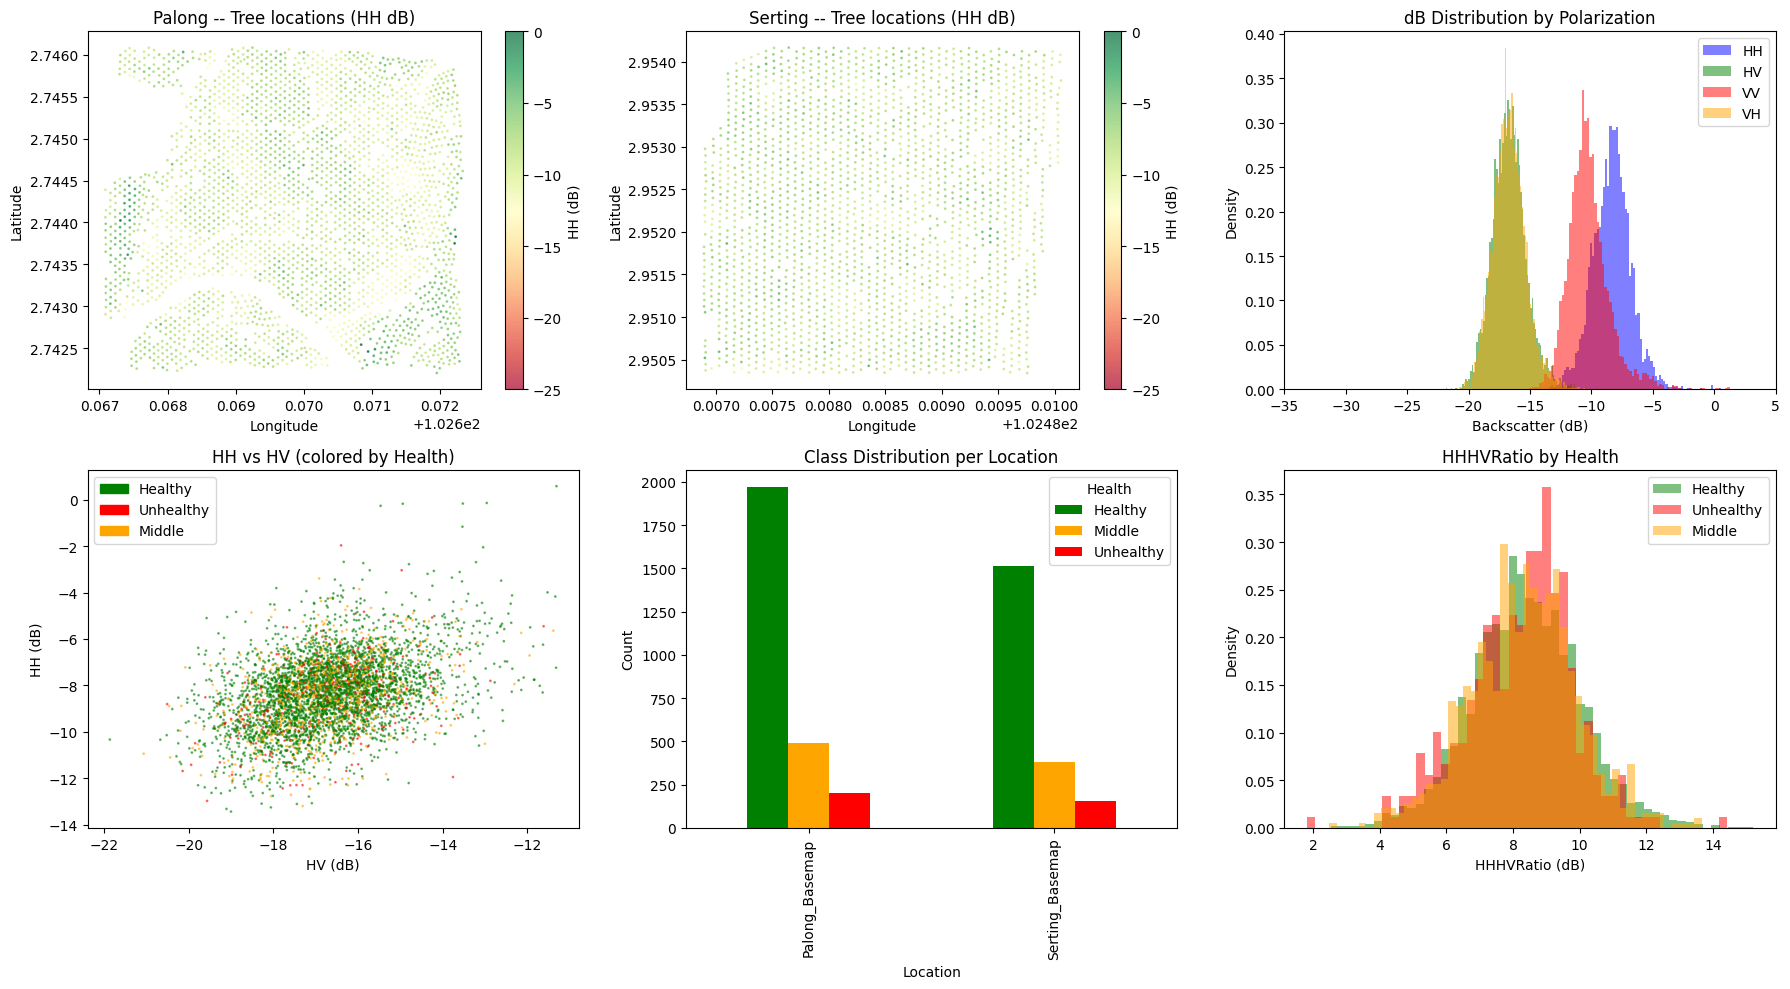

Visual QA saved to /content/SAR-OilPalm/data/processed/visual_qa.png


In [24]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

combined = pd.concat(
    [df.assign(Location=loc) for loc, df in datasets.items()],
    ignore_index=True
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
HEALTH_COLORS = {'Healthy': 'green', 'Unhealthy': 'red', 'Middle': 'orange'}

# --- Plot 1: Palong tree locations (HH dB) ---
ax = axes[0, 0]
df_p = datasets['Palong_Basemap']
sc = ax.scatter(df_p['Long'], df_p['Lat'], c=df_p['HH'],
                cmap='RdYlGn', s=1, alpha=0.7, vmin=-25, vmax=0)
plt.colorbar(sc, ax=ax, label='HH (dB)')
ax.set_title('Palong -- Tree locations (HH dB)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

# --- Plot 2: Serting tree locations (HH dB) ---
ax = axes[0, 1]
df_s = datasets['Serting_Basemap']
sc = ax.scatter(df_s['Long'], df_s['Lat'], c=df_s['HH'],
                cmap='RdYlGn', s=1, alpha=0.7, vmin=-25, vmax=0)
plt.colorbar(sc, ax=ax, label='HH (dB)')
ax.set_title('Serting -- Tree locations (HH dB)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

# --- Plot 3: dB distributions ---
ax = axes[0, 2]
for pol, color in [('HH', 'blue'), ('HV', 'green'), ('VV', 'red'), ('VH', 'orange')]:
    if pol in combined.columns:
        vals = combined[pol].dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=80, alpha=0.5, label=pol, color=color, density=True)
ax.set_xlabel('Backscatter (dB)')
ax.set_ylabel('Density')
ax.set_title('dB Distribution by Polarization')
ax.legend()
ax.set_xlim(-35, 5)

# --- Plot 4: HH vs HV scatter ---
ax = axes[1, 0]
valid = combined['HH'].notna() & combined['HV'].notna()
colors = combined.loc[valid, 'Health'].map(HEALTH_COLORS).fillna('gray')
ax.scatter(combined.loc[valid, 'HV'], combined.loc[valid, 'HH'],
           c=colors, s=1, alpha=0.5)
ax.set_xlabel('HV (dB)')
ax.set_ylabel('HH (dB)')
ax.set_title('HH vs HV (colored by Health)')
ax.legend(handles=[Patch(color=c, label=l) for l, c in HEALTH_COLORS.items()],
          markerscale=5)

# --- Plot 5: Class distribution per location ---
ax = axes[1, 1]
class_counts = combined.groupby(['Location', 'Health']).size().unstack(fill_value=0)
class_counts.plot(kind='bar', ax=ax,
                  color=[HEALTH_COLORS.get(c, 'gray') for c in class_counts.columns])
ax.set_title('Class Distribution per Location')
ax.set_xlabel('Location'); ax.set_ylabel('Count')
ax.legend(title='Health')

# --- Plot 6: HHHVRatio by Health class ---
ax = axes[1, 2]
for cls, color in HEALTH_COLORS.items():
    vals = combined.loc[combined['Health'] == cls, 'HHHVRatio'].dropna()
    if len(vals) > 0:
        ax.hist(vals, bins=50, alpha=0.5, label=cls, color=color, density=True)
ax.set_xlabel('HHHVRatio (dB)')
ax.set_ylabel('Density')
ax.set_title('HHHVRatio by Health')
ax.legend()

plt.tight_layout()
qa_path = f"{OUTPUT_DIR}/visual_qa.png"
plt.savefig(qa_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Visual QA saved to {qa_path}")

---

## Datasets Preparation

Dataset CSVs are ready at `data/processed/dataset_<location>.csv`.

**Schema**: `id, Long, Lat, HH, HV, VV, VH, HHHVRatio, Health, Tier`

Next steps are in the preparation for ML Classifier:
1. Dropping `id, Long, Lat, VH, Tier`
2. Feature: `HH, HV, VV, HHHVRatio`
3. Label: `Health`
4. Statified split at 80:20 ratio (adjustable)
5. (Optional Block) Feature Scaling on Training Set with Z-Score Normalisataion
6. (Optional Block) SMOTE with KNN and synthetic data balancing

---

## ML1 - Random Forest

Random forest ML implementation, can be parallelized with tunable hyperparameters\
Since the datasets might be imbalance, it can optionally have Startified K-fold Cross Validation

---

## ML2 - XGBoost

XGBoost ML implementation, with tunable hyperparameters aswell\
Since this is also training based, it can optionally have Startified K-fold Cross Validation

---

## ML3 - TabFM

TabFM Foundation Model implementation, no training needed as far I'm aware.